# 07d — Dual-Stream Conv-LSTM M02: RGB + Lucas-Kanade P17 (Gabungan)

Notebook ini menggabungkan **dua arsitektur M02** dari eksperimen OFAT:
- Stream RGB  : `05b_M02_LSTM_H2_128.ipynb` (baseline M02)
- Stream Flow : `06_P17_M02_Training.ipynb` (LK P17 M02)

---

## Analisis Persamaan dan Perbedaan Kedua Model

### ✅ Yang SAMA (identik)
| Komponen | M02 Baseline | P17-M02 |
|---|---|---|
| Arsitektur kelas | `ConvLSTMModel` | `ConvLSTMModel` |
| CNN channels | `[32, 64, 128]` | `[32, 64, 128]` |
| LSTM hidden | `[128, 128]` ← M02 variant | `[128, 128]` ← M02 variant |
| FC hidden | `256` | `256` |
| Dropout | `0.5` | `0.5` |
| Optimizer | Adam, LR=0.001, WD=1e-5 | Adam, LR=0.001, WD=1e-5 |
| Scheduler | ReduceLROnPlateau patience=5 | ReduceLROnPlateau patience=5 |
| Batch size | 8 | 8 |
| Grad clip | `max_norm=1.0` | `max_norm=1.0` |
| Total params | 2,491,666 | 2,491,666 |

**Kesimpulan:** Kedua model secara arsitektur **identik** — keduanya adalah varian M02 dari OFAT LSTM hidden size. Perbedaan hanya pada **sumber input**.

### ❌ Yang BERBEDA (input modality)
| Komponen | M02 Baseline | P17-M02 |
|---|---|---|
| Input | `raw_lips` (RGB) | `flows_lk_p17` (LK P17) |
| Seq len | 30 frames | 29 frames (T-1) |
| Nilai range | [0, 1] (dibagi 255) | z-score (~[-2.5, 2.9]) |
| Channels | RGB (R, G, B) | Flow (u, v, magnitude) |
| Augmentasi | Tidak ada | Flip + negate u |

### 🔍 Apa yang baru di M02 vs arsitektur baseline sebelumnya?
LSTM layer-2 dinaikkan dari **64 → 128** hidden channels.  
Ini berarti feature vector output encoder berubah dari **64-dim → 128-dim**, sehingga:
- `AttentionFusion` bekerja di ruang 128-dim
- Gate: `w_rgb = Linear(256, 128)`, `w_flow = Linear(256, 128)`
- Fused feature: `[B, 128]`

### 📊 Hasil pembanding
| Model | Val Acc | Test Acc | F1 (weighted) | Best Epoch |
|---|---|---|---|---|
| M02 Baseline (RGB) | 85.97% | 85.00% | 84.83% | 59 |
| P17-M02 (LK Flow) | 51.53% | 53.48% | 54.03% | 97 |
| **Dual-Stream M02 (ini)** | ? | ? | ? | ? |

---


In [1]:
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [2]:
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RGB_DIR      = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
FLOW_DIR     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lk_p17'
MODELS_DIR   = PROJECT_ROOT / 'models' / 'dual_stream' / 'M02'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'dual_stream' / 'M02'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

# ── Parameter M02 (identik di kedua single-stream) ──────────────────────────
VARIANT_ID   = 'Dual-M02'
CNN_CHANNELS = [32, 64, 128]
LSTM_HIDDENS = [128, 128]      # M02: layer-2 = 128 (bukan 64 seperti baseline)
DROPOUT      = 0.5
FC_HIDDEN    = 256
RGB_SEQ_LEN  = 30              # frame RGB
FLOW_SEQ_LEN = 29              # frame flow = T-1

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f'Variant  : {VARIANT_ID}')
print(f'CNN ch   : {CNN_CHANNELS}')
print(f'LSTM h   : {LSTM_HIDDENS}  (M02: layer-2 = 128, bukan 64)')
print(f'Dropout  : {DROPOUT} | FC: {FC_HIDDEN}')
print(f'RGB seq  : {RGB_SEQ_LEN} frames | Flow seq: {FLOW_SEQ_LEN} frames')
print(f'Classes  : {NUM_CLASSES} — {CLASSES}')

Variant  : Dual-M02
CNN ch   : [32, 64, 128]
LSTM h   : [128, 128]  (M02: layer-2 = 128, bukan 64)
Dropout  : 0.5 | FC: 256
RGB seq  : 30 frames | Flow seq: 29 frames
Classes  : 18 — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']


In [3]:
class DualStreamDataset(Dataset):
    """
    Load pasangan (RGB, LK P17 flow) untuk dual-stream M02.

    RGB  : raw_lips     → [T, H, W, 3] uint8, dibagi 255
    Flow : flows_lk_p17 → [T-1, H, W, 3] float32, sudah z-score (P17 params)

    Augmentasi train:
      - Horizontal flip + negate u channel pada flow.
        Negate u wajib karena u merepresentasikan perpindahan horizontal
        — tanpa negate, arah gerak jadi kebalik semantiknya.
    """

    def __init__(self, rgb_dir, flow_dir, classes, split,
                 rgb_seq=30, flow_seq=29, augment=False):
        self.rgb_dir  = Path(rgb_dir)
        self.flow_dir = Path(flow_dir)
        self.rgb_seq  = rgb_seq
        self.flow_seq = flow_seq
        self.augment  = augment
        cls_map       = {c: i for i, c in enumerate(classes)}

        self.samples = []
        for cls in classes:
            for rf in sorted((self.rgb_dir / split / cls).glob('*.npy')):
                ff = self.flow_dir / split / cls / rf.name
                if ff.exists():
                    self.samples.append((rf, ff, cls_map[cls]))

        # verifikasi pasangan
        miss = 0
        for cls in classes:
            rn = len(list((self.rgb_dir  / split / cls).glob('*.npy')))
            fn = len(list((self.flow_dir / split / cls).glob('*.npy')))
            if rn != fn: miss += abs(rn - fn)
        if miss:
            print(f'  Warning: {miss} file tidak berpasangan di split={split}')
        print(f'  {split:5s}: {len(self.samples)} pasangan')

    def _fix_len(self, s, target):
        T = len(s)
        if T == target: return s
        if T < target:
            pad = np.zeros((target - T, *s.shape[1:]), dtype=np.float32)
            return np.concatenate([s, pad])
        return s[np.linspace(0, T - 1, target, dtype=int)]

    def _aug(self, rgb, flow):
        if np.random.random() > 0.5:
            rgb  = rgb[:, :, ::-1, :].copy()
            flow = flow[:, :, ::-1, :].copy()
            flow[..., 0] *= -1   # negate u (horizontal displacement)
        return rgb, flow

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        rf, ff, label = self.samples[i]
        rgb  = np.load(rf).astype(np.float32) / 255.0   # [T, H, W, 3]
        flow = np.load(ff).astype(np.float32)            # [T-1, H, W, 3]

        if self.augment: rgb, flow = self._aug(rgb, flow)

        rgb  = self._fix_len(rgb,  self.rgb_seq)
        flow = self._fix_len(flow, self.flow_seq)

        rgb  = torch.from_numpy(rgb.transpose(3, 0, 1, 2))   # [C, T, H, W]
        flow = torch.from_numpy(flow.transpose(3, 0, 1, 2))
        return rgb, flow, torch.tensor(label, dtype=torch.long)


print('Loading datasets...')
train_ds = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'train',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=True)
val_ds   = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'val',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)
test_ds  = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'test',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)

kw = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

rgb_b, flow_b, lbl_b = next(iter(train_loader))
print(f'\nRGB  batch  : {rgb_b.shape}   range [{rgb_b.min():.3f}, {rgb_b.max():.3f}]')
print(f'Flow batch  : {flow_b.shape}   range [{flow_b.min():.3f}, {flow_b.max():.3f}]')
print(f'Label sample: {[IDX_TO_CLASS[l.item()] for l in lbl_b]}')

Loading datasets...
  train: 2519 pasangan
  val  : 720 pasangan
  test : 359 pasangan

RGB  batch  : torch.Size([8, 3, 30, 96, 96])   range [0.000, 1.000]
Flow batch  : torch.Size([8, 3, 29, 96, 96])   range [-2.432, 2.918]
Label sample: ['8', 'b', 'sekarang', '3', '9', 'keliling', 'kelompok', '2']


In [4]:
# ── ConvLSTM Cell ────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))


# ── Stream Encoder (identik M02 tapi output feature, bukan logit) ────────────
class StreamEncoder(nn.Module):
    """
    Encoder per-stream dengan konfigurasi M02:
    CNN [32→64→128] + LSTM [128→128] → GAP → feature [B, 128].

    Perbedaan dari encoder baseline (07c): output 128-dim, bukan 64-dim,
    karena LSTM layer-2 di M02 dinaikkan dari 64 → 128 hidden channels.
    """
    def __init__(self, in_ch=3, cnn_channels=None, lstm_hiddens=None):
        super().__init__()
        cnn_channels = cnn_channels or [32, 64, 128]
        lstm_hiddens = lstm_hiddens or [128, 128]

        def cblock(ic, oc):
            return nn.Sequential(nn.Conv2d(ic, oc, 3, padding=1),
                                 nn.BatchNorm2d(oc), nn.ReLU(), nn.MaxPool2d(2))
        layers, prev = [], in_ch
        for ch in cnn_channels:
            layers.append(cblock(prev, ch)); prev = ch
        self.cnn = nn.Sequential(*layers)

        self.lstm_cells = nn.ModuleList()
        for h_ch in lstm_hiddens:
            self.lstm_cells.append(ConvLSTMCell(prev, h_ch))
            prev = h_ch
        self.out_dim = lstm_hiddens[-1]

    def forward(self, x):
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)
        states = [cell.init_hidden(B, h, w, x.device) for cell in self.lstm_cells]
        for t in range(T):
            inp = x[:, t]
            for li, cell in enumerate(self.lstm_cells):
                states[li] = cell(inp, states[li])
                inp = states[li][0]
        return states[-1][0].mean(dim=[-2, -1])   # [B, lstm_hiddens[-1]]


# ── Attention Fusion ──────────────────────────────────────────────────────────
class AttentionFusion(nn.Module):
    """
    Bobot adaptif per stream.
    Karena M02 menggunakan 128-dim feature (vs 64-dim di baseline),
    gate input adalah concat 256-dim, dan output gate adalah 128-dim.

    g_rgb  = sigmoid(W_rgb  @ [rgb_feat; flow_feat])
    g_flow = sigmoid(W_flow @ [rgb_feat; flow_feat])
    fused  = g_rgb * rgb_feat + g_flow * flow_feat
    """
    def __init__(self, feat_dim=128):
        super().__init__()
        self.w_rgb  = nn.Linear(feat_dim * 2, feat_dim)
        self.w_flow = nn.Linear(feat_dim * 2, feat_dim)

    def forward(self, rgb_feat, flow_feat):
        combined  = torch.cat([rgb_feat, flow_feat], dim=1)   # [B, 256]
        gate_rgb  = torch.sigmoid(self.w_rgb(combined))       # [B, 128]
        gate_flow = torch.sigmoid(self.w_flow(combined))      # [B, 128]
        return gate_rgb * rgb_feat + gate_flow * flow_feat    # [B, 128]


# ── Model Utama ───────────────────────────────────────────────────────────────
class DualStreamM02(nn.Module):
    """
    Dual-Stream Conv-LSTM M02:
    - RGB stream  → StreamEncoder(M02) → rgb_feat  [B, 128]
    - Flow stream → StreamEncoder(M02) → flow_feat [B, 128]
    - AttentionFusion → fused [B, 128]
    - Head: FC(128→256) + ReLU + Dropout + FC(256→N)
    """
    def __init__(self, num_classes, cnn_channels, lstm_hiddens, dropout=0.5, fc_hidden=256):
        super().__init__()
        feat_dim = lstm_hiddens[-1]   # 128 untuk M02
        self.rgb_enc  = StreamEncoder(in_ch=3, cnn_channels=cnn_channels, lstm_hiddens=lstm_hiddens)
        self.flow_enc = StreamEncoder(in_ch=3, cnn_channels=cnn_channels, lstm_hiddens=lstm_hiddens)
        self.fusion   = AttentionFusion(feat_dim=feat_dim)
        self.head     = nn.Sequential(
            nn.Linear(feat_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes)
        )

    def forward(self, rgb, flow):
        rgb_feat  = self.rgb_enc(rgb)
        flow_feat = self.flow_enc(flow)
        fused     = self.fusion(rgb_feat, flow_feat)
        return self.head(fused)


model = DualStreamM02(NUM_CLASSES, CNN_CHANNELS, LSTM_HIDDENS, DROPOUT, FC_HIDDEN).to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

# inference time
dummy_rgb  = torch.randn(1, 3, RGB_SEQ_LEN,  96, 96).to(device)
dummy_flow = torch.randn(1, 3, FLOW_SEQ_LEN, 96, 96).to(device)
model.eval()
with torch.no_grad():
    for _ in range(5): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    infer_ms = (time.time() - t0) / 50 * 1000
model.train()

with torch.no_grad():
    out_test = model(torch.randn(2,3,RGB_SEQ_LEN,96,96).to(device),
                     torch.randn(2,3,FLOW_SEQ_LEN,96,96).to(device))

print(f'Variant       : {VARIANT_ID}')
print(f'CNN ch        : {CNN_CHANNELS}')
print(f'LSTM h        : {LSTM_HIDDENS}  (M02: layer-2 = 128)')
print(f'Feat dim      : {LSTM_HIDDENS[-1]} (64→128 dibanding baseline)')
print(f'Total params  : {total_params:,}')
print(f'Model size    : {model_size_mb:.2f} MB')
print(f'Inference time: {infer_ms:.2f} ms/sample')
print(f'Forward test  : {out_test.shape}  ✓')

Variant       : Dual-M02
CNN ch        : [32, 64, 128]
LSTM h        : [128, 128]  (M02: layer-2 = 128)
Feat dim      : 128 (64→128 dibanding baseline)
Total params  : 5,011,474
Model size    : 20.05 MB
Inference time: 20.19 ms/sample
Forward test  : torch.Size([2, 18])  ✓


In [5]:
# scheduler patience=8 untuk dual-stream (lebih lama stabil dibanding single)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)
criterion = nn.CrossEntropyLoss()


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for rgb, flow, y in tqdm(loader, leave=False, desc='Train' if train else 'Eval '):
            rgb, flow, y = rgb.to(device), flow.to(device), y.to(device)
            out  = model(rgb, flow)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            preds_all.extend(out.argmax(1).cpu().tolist())
            labels_all.extend(y.cpu().tolist())
    return total_loss / len(loader.dataset), 100 * accuracy_score(labels_all, preds_all), preds_all, labels_all


def per_class_str(labels, preds):
    res = []
    for i, cls in enumerate(CLASSES):
        tot = sum(l == i for l in labels)
        if tot == 0: continue
        acc = round(100 * sum(p == i for p, l in zip(preds, labels) if l == i) / tot)
        res.append(f'{cls}:{acc}%')
    return '  '.join(res)


print('Setup selesai')
print(f'Scheduler patience: 8 (dual-stream perlu lebih lama stabil)')

Setup selesai
Scheduler patience: 8 (dual-stream perlu lebih lama stabil)


In [6]:
history   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[], 'epoch_time':[]}
best_val  = 0.0; best_ep = 0
best_path = MODELS_DIR / f'{VARIANT_ID}_best.pth'
t0_total  = time.time()

print(f'Training {VARIANT_ID} — {NUM_EPOCHS} epochs | {NUM_CLASSES} kelas')
print(f'RGB: {RGB_SEQ_LEN}fr | Flow (P17): {FLOW_SEQ_LEN}fr | Feat dim: {LSTM_HIDDENS[-1]}\n')

for ep in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, _, _       = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_p, va_l = run_epoch(val_loader,   train=False)
    scheduler.step(va_acc)
    cur_lr = optimizer.param_groups[0]['lr']
    ep_t   = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(ep_t)

    mark = ''
    if va_acc > best_val:
        best_val = va_acc; best_ep = ep
        torch.save({
            'model_state' : model.state_dict(),
            'epoch'       : ep,
            'val_acc'     : va_acc,
            'variant'     : VARIANT_ID,
            'cnn_channels': CNN_CHANNELS,
            'lstm_hiddens': LSTM_HIDDENS,
            'flow_config' : 'P17'
        }, best_path)
        mark = '  <-- best'

    print(f'{ep:4d}  loss={tr_loss:.4f} tr={tr_acc:.2f}%  val={va_acc:.2f}%  lr={cur_lr:.2e}  {ep_t:.0f}s{mark}')
    if ep % 5 == 0 or mark:
        print(f'       per-class: {per_class_str(va_l, va_p)}')

total_time = time.time() - t0_total
print(f'\nTraining selesai! Best val={best_val:.2f}% di epoch {best_ep} | Total={total_time/60:.1f} menit')

Training Dual-M02 — 100 epochs | 18 kelas
RGB: 30fr | Flow (P17): 29fr | Feat dim: 128



Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

   1  loss=2.9031 tr=5.60%  val=5.56%  lr=1.00e-03  136s  <-- best
       per-class: 1:0%  2:0%  3:0%  8:0%  9:0%  10:0%  a:0%  b:0%  c:0%  d:0%  e:0%  f:0%  buku:0%  dia:0%  saya:0%  keliling:0%  kelompok:100%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

  99  loss=0.0042 tr=99.84%  val=85.56%  lr=1.25e-04  135s


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

 100  loss=0.0024 tr=99.96%  val=84.44%  lr=1.25e-04  135s
       per-class: 1:98%  2:92%  3:88%  8:92%  9:92%  10:92%  a:100%  b:98%  c:72%  d:68%  e:70%  f:88%  buku:98%  dia:65%  saya:80%  keliling:80%  kelompok:80%  sekarang:68%

Training selesai! Best val=87.22% di epoch 83 | Total=225.4 menit


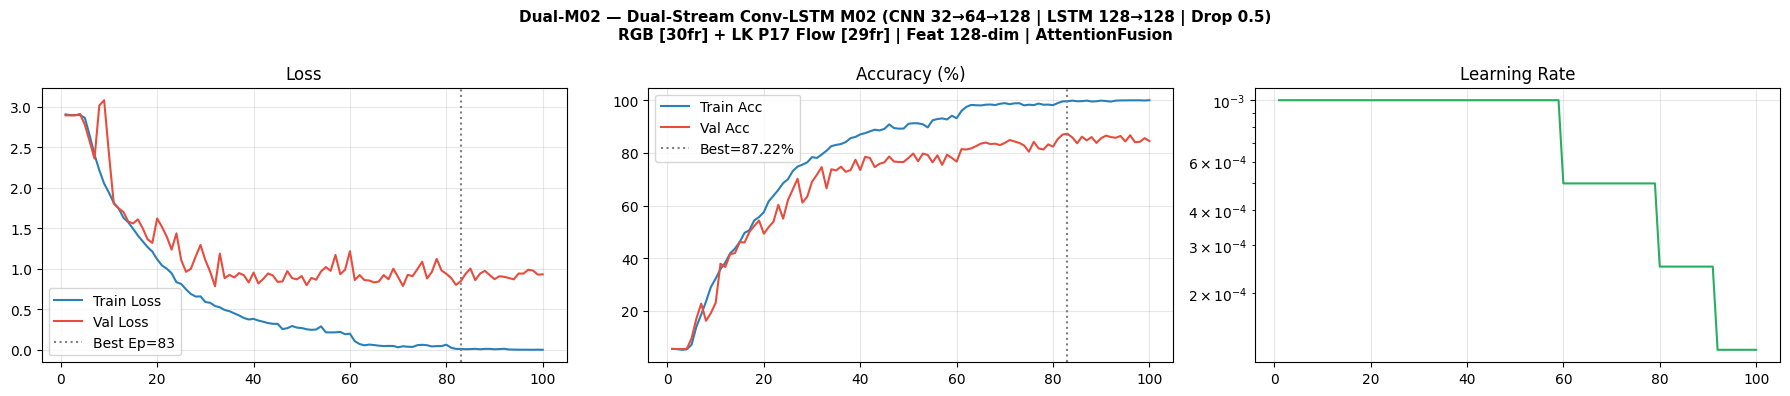

Saved: training_curves.png


In [7]:
eps = range(1, len(history['train_acc']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(
    f'{VARIANT_ID} — Dual-Stream Conv-LSTM M02 (CNN 32→64→128 | LSTM 128→128 | Drop 0.5)\n'
    f'RGB [30fr] + LK P17 Flow [29fr] | Feat 128-dim | AttentionFusion',
    fontsize=11, fontweight='bold')

axes[0].plot(eps, history['train_loss'], label='Train Loss', color='#2980B9')
axes[0].plot(eps, history['val_loss'],   label='Val Loss',   color='#E74C3C')
axes[0].axvline(best_ep, color='gray', linestyle=':', label=f'Best Ep={best_ep}')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['train_acc'], label='Train Acc', color='#2980B9')
axes[1].plot(eps, history['val_acc'],   label='Val Acc',   color='#E74C3C')
axes[1].axvline(best_ep, color='gray', linestyle=':', label=f'Best={best_val:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].semilogy(eps, history['lr'], color='#27AE60')
axes[2].set_title('Learning Rate'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [8]:
ckpt = torch.load(best_path, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best model epoch {ckpt["epoch"]} (val={ckpt["val_acc"]:.2f}%)\n')

te_loss, te_acc, te_p, te_l = run_epoch(test_loader, train=False)

report    = classification_report(te_l, te_p, target_names=CLASSES, output_dict=True)
f1_macro  = report['macro avg']['f1-score'] * 100
f1_weight = report['weighted avg']['f1-score'] * 100
prec_w    = report['weighted avg']['precision'] * 100
rec_w     = report['weighted avg']['recall'] * 100

class_accs = []
for i in range(NUM_CLASSES):
    tot = sum(l == i for l in te_l)
    class_accs.append(100 * sum(p == i for p, l in zip(te_p, te_l) if l == i) / tot if tot else 0)

print('=' * 60)
print(f'  HASIL TEST — {VARIANT_ID}')
print('=' * 60)
print(f'  Test Accuracy  : {te_acc:.2f}%')
print(f'  F1 Weighted    : {f1_weight:.2f}%')
print(f'  F1 Macro       : {f1_macro:.2f}%')
print(f'  Precision (w)  : {prec_w:.2f}%')
print(f'  Recall (w)     : {rec_w:.2f}%')
print(f'  Best Epoch     : {best_ep}/{NUM_EPOCHS}')
print(f'  Best Val Acc   : {best_val:.2f}%')
print('=' * 60)
print('\nPer-class accuracy:')
for cls, acc in zip(CLASSES, class_accs):
    flag = '✓' if acc >= 80 else ('△' if acc >= 50 else '✗')
    print(f'  {flag} {cls:12s}: {acc:.1f}%')

print('\nClassification Report:')
print(classification_report(te_l, te_p, target_names=CLASSES, digits=3))

Loaded best model epoch 83 (val=87.22%)



Eval :   0%|          | 0/45 [00:00<?, ?it/s]

  HASIL TEST — Dual-M02
  Test Accuracy  : 86.63%
  F1 Weighted    : 86.60%
  F1 Macro       : 86.61%
  Precision (w)  : 86.85%
  Recall (w)     : 86.63%
  Best Epoch     : 83/100
  Best Val Acc   : 87.22%

Per-class accuracy:
  ✓ 1           : 100.0%
  ✓ 2           : 90.0%
  ✓ 3           : 85.0%
  ✓ 8           : 100.0%
  ✓ 9           : 94.7%
  ✓ 10          : 95.0%
  ✓ a           : 100.0%
  ✓ b           : 95.0%
  △ c           : 75.0%
  ✓ d           : 80.0%
  △ e           : 75.0%
  ✓ f           : 95.0%
  ✓ buku        : 90.0%
  ✓ dia         : 80.0%
  ✓ saya        : 80.0%
  △ keliling    : 75.0%
  △ kelompok    : 75.0%
  △ sekarang    : 75.0%

Classification Report:
              precision    recall  f1-score   support

           1      0.952     1.000     0.976        20
           2      0.947     0.900     0.923        20
           3      0.850     0.850     0.850        20
           8      0.909     1.000     0.952        20
           9      0.900     0.947     0.923

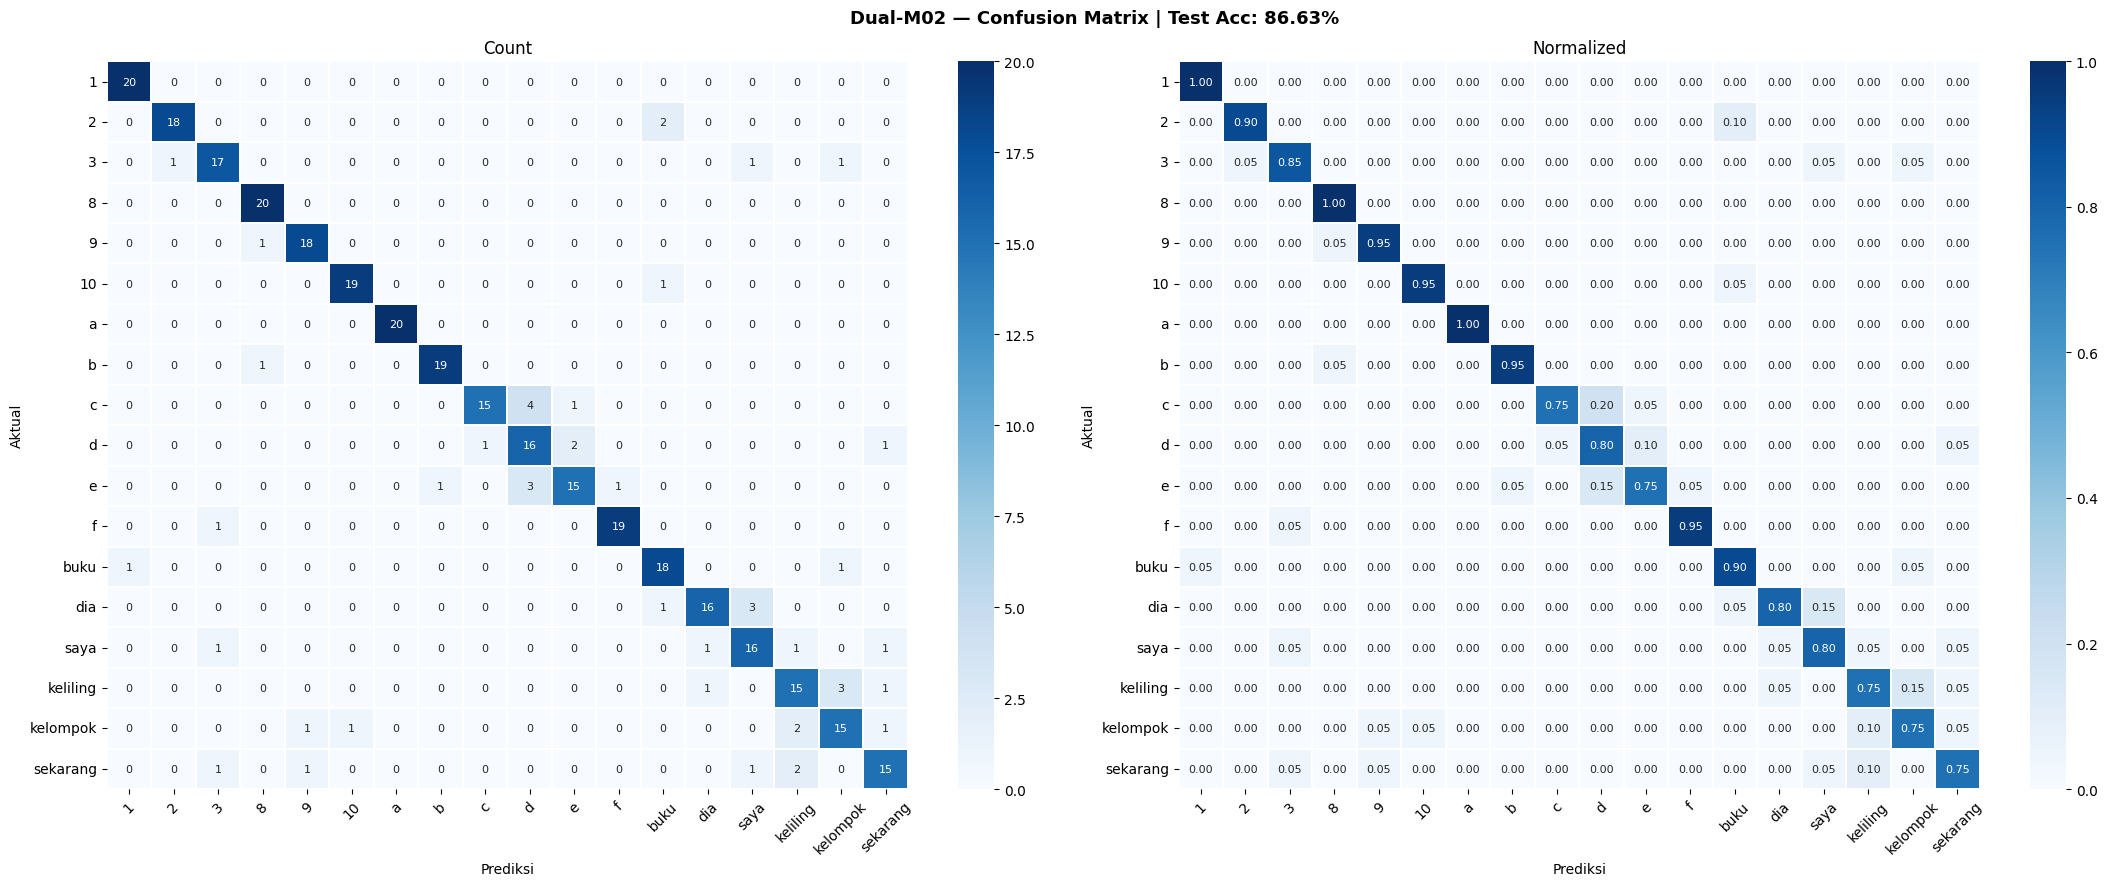

Saved: confusion_matrix.png


In [9]:
cm  = confusion_matrix(te_l, te_p)
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(f'{VARIANT_ID} — Confusion Matrix | Test Acc: {te_acc:.2f}%',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8}, linewidths=0.3)
axes[0].set_title('Count'); axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8},
            vmin=0, vmax=1, linewidths=0.3)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

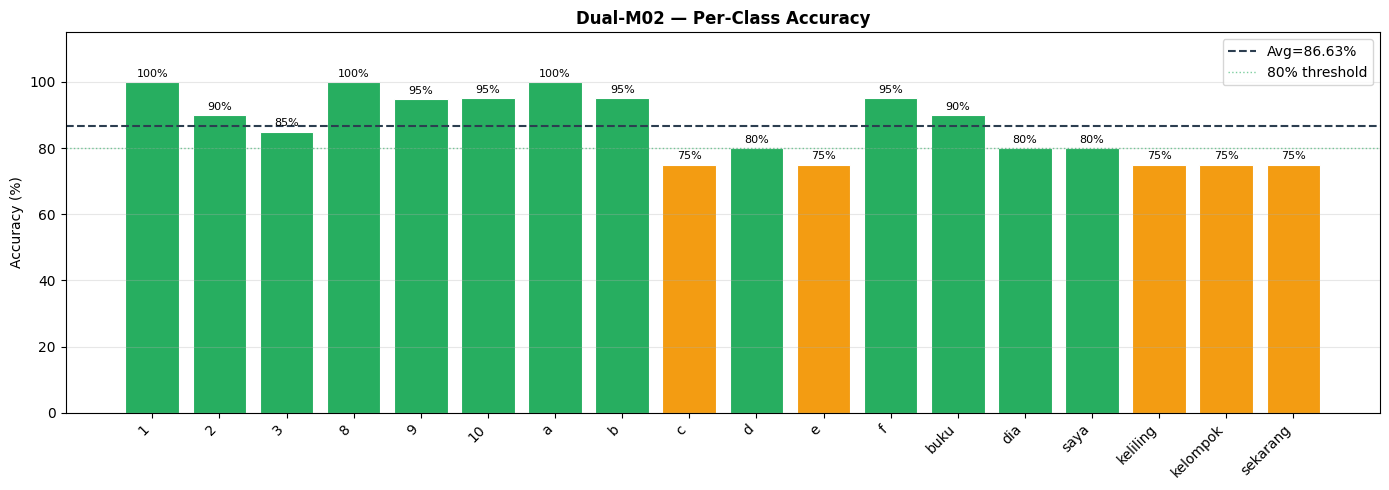

Saved: per_class_accuracy.png


In [10]:
x_pos  = np.arange(NUM_CLASSES)
colors = ['#27AE60' if a >= 80 else ('#F39C12' if a >= 50 else '#E74C3C') for a in class_accs]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x_pos, class_accs, color=colors, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(te_acc, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'Avg={te_acc:.2f}%')
ax.axhline(80, color='#27AE60', linestyle=':', linewidth=1, alpha=0.6, label='80% threshold')
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim([0, 115])
ax.set_title(f'{VARIANT_ID} — Per-Class Accuracy', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

PERBANDINGAN MODEL M02 — Dataset Gabungan (18 kelas)
Metode                                           Val    Test    F1-w    Ep
------------------------------------------------------------------------------
M02 Baseline (RGB only)                       85.97%   85.00%   84.83%    59
P17-M02 (LK P17 only)                         51.53%   53.48%   54.03%    97
Dual-M02 (RGB + LK P17, ini)                  87.22%   86.63%   86.60%    83

Delta Dual vs RGB baseline  — Test: +1.63%
Delta Dual vs LK P17 single — Test: +33.15%


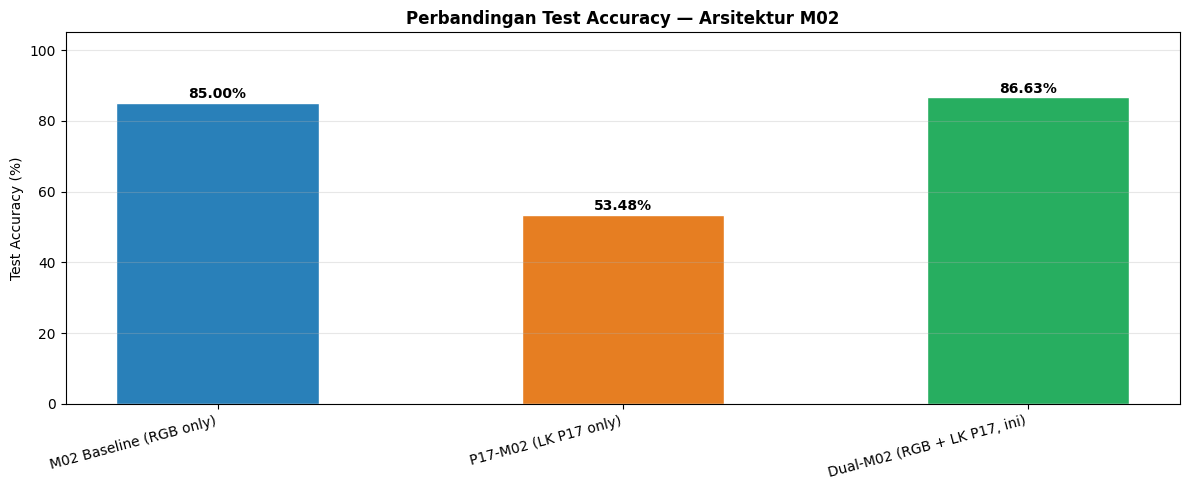

Saved: comparison_bar.png


In [11]:
# ── Perbandingan lengkap semua model M02 ─────────────────────────────────────
comparison = {
    'M02 Baseline (RGB only)'           : {'val': 85.97, 'test': 85.00, 'f1w': 84.83, 'ep': 59},
    'P17-M02 (LK P17 only)'             : {'val': 51.53, 'test': 53.48, 'f1w': 54.03, 'ep': 97},
    f'{VARIANT_ID} (RGB + LK P17, ini)' : {'val': best_val, 'test': te_acc, 'f1w': f1_weight, 'ep': best_ep},
}

print('=' * 78)
print('PERBANDINGAN MODEL M02 — Dataset Gabungan (18 kelas)')
print('=' * 78)
print(f'{"Metode":<44} {"Val":>7} {"Test":>7} {"F1-w":>7} {"Ep":>5}')
print('-' * 78)
for nama, r in comparison.items():
    print(f'{nama:<44} {r["val"]:>6.2f}%  {r["test"]:>6.2f}%  {r["f1w"]:>6.2f}%  {r["ep"]:>4}')
print('=' * 78)

# Delta dual vs single-stream
delta_vs_rgb   = te_acc - comparison['M02 Baseline (RGB only)']['test']
delta_vs_flow  = te_acc - comparison['P17-M02 (LK P17 only)']['test']
print(f'\nDelta Dual vs RGB baseline  — Test: {delta_vs_rgb:+.2f}%')
print(f'Delta Dual vs LK P17 single — Test: {delta_vs_flow:+.2f}%')

# visualisasi bar perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
metode  = list(comparison.keys())
test_scores = [comparison[m]['test'] for m in metode]
colors_cmp  = ['#2980B9', '#E67E22', '#27AE60']
bars = ax.bar(metode, test_scores, color=colors_cmp, edgecolor='white', width=0.5)
for bar, sc in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{sc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)'); ax.set_ylim([0, 105])
ax.set_title('Perbandingan Test Accuracy — Arsitektur M02', fontsize=12, fontweight='bold')
ax.set_xticklabels(metode, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: comparison_bar.png')

In [12]:
summary = {
    'variant_id'  : VARIANT_ID,
    'variant_name': f'{VARIANT_ID} — Dual-Stream M02 (CNN 32→64→128 | LSTM 128→128 | Feat 128-dim)',
    'architecture': {
        'rgb_encoder' : 'StreamEncoder M02: CNN [32,64,128] + LSTM [128,128] → 128-dim',
        'flow_encoder': 'StreamEncoder M02: CNN [32,64,128] + LSTM [128,128] → 128-dim',
        'fusion'      : 'AttentionFusion (feat_dim=128, gate 256→128)',
        'head'        : 'FC(128→256) + ReLU + Dropout(0.5) + FC(256→N)'
    },
    'vs_single_stream': {
        'M02_baseline_test': 85.00,
        'P17_M02_test'     : 53.48,
        'note'             : 'Kedua encoder identik secara arsitektur, berbeda di input modality'
    },
    'config': {
        'cnn_channels': CNN_CHANNELS, 'lstm_hiddens': LSTM_HIDDENS,
        'feat_dim': LSTM_HIDDENS[-1],
        'dropout': DROPOUT, 'fc_hidden': FC_HIDDEN,
        'rgb_seq': RGB_SEQ_LEN, 'flow_seq': FLOW_SEQ_LEN,
        'flow_config': 'P17 (maxCorners=300, qualityLevel=0.005, blockSize=6)'
    },
    'training': {
        'total_params': total_params, 'trainable_params': trainable_params,
        'model_size_mb': round(model_size_mb, 2),
        'inference_ms' : round(infer_ms, 2),
        'best_epoch': best_ep, 'best_val_acc': round(best_val, 4),
        'batch_size': BATCH_SIZE, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'scheduler_patience': 8,
        'total_time_min': round(total_time / 60, 2),
        'avg_epoch_sec' : round(sum(history['epoch_time']) / len(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss': round(te_loss, 4), 'accuracy': round(te_acc, 4),
        'f1_macro': round(f1_macro, 4), 'f1_weighted': round(f1_weight, 4),
        'precision_weighted': round(prec_w, 4), 'recall_weighted': round(rec_w, 4),
        'per_class_acc': {CLASSES[i]: round(class_accs[i], 2) for i in range(NUM_CLASSES)}
    }
}

with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'epoch': range(1, len(history['train_loss'])+1),
    'train_loss': history['train_loss'], 'train_acc': history['train_acc'],
    'val_loss'  : history['val_loss'],   'val_acc'  : history['val_acc'],
    'lr': history['lr'], 'epoch_time': history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

pd.DataFrame(
    [{'class': cls, **{k: round(report[cls][k]*100, 2) for k in ['precision','recall','f1-score']},
      'support': int(report[cls]['support'])} for cls in CLASSES]
).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print(f'=== {VARIANT_ID} — Semua Hasil Tersimpan ===')
for fname in ['summary.json', 'training_history.csv', 'classification_report.csv',
              'training_curves.png', 'confusion_matrix.png',
              'per_class_accuracy.png', 'comparison_bar.png']:
    p = RESULTS_DIR / fname
    print(f'  [{"✓" if p.exists() else "○"}] {fname}')

print(f'\nTest Accuracy  : {te_acc:.2f}%')
print(f'F1 Weighted    : {f1_weight:.2f}%')
print(f'Best Epoch     : {best_ep}/{NUM_EPOCHS}')
print(f'Delta vs Baseline — Test: {te_acc - 85.00:+.2f}%')

=== Dual-M02 — Semua Hasil Tersimpan ===
  [✓] summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png
  [✓] comparison_bar.png

Test Accuracy  : 86.63%
F1 Weighted    : 86.60%
Best Epoch     : 83/100
Delta vs Baseline — Test: +1.63%
